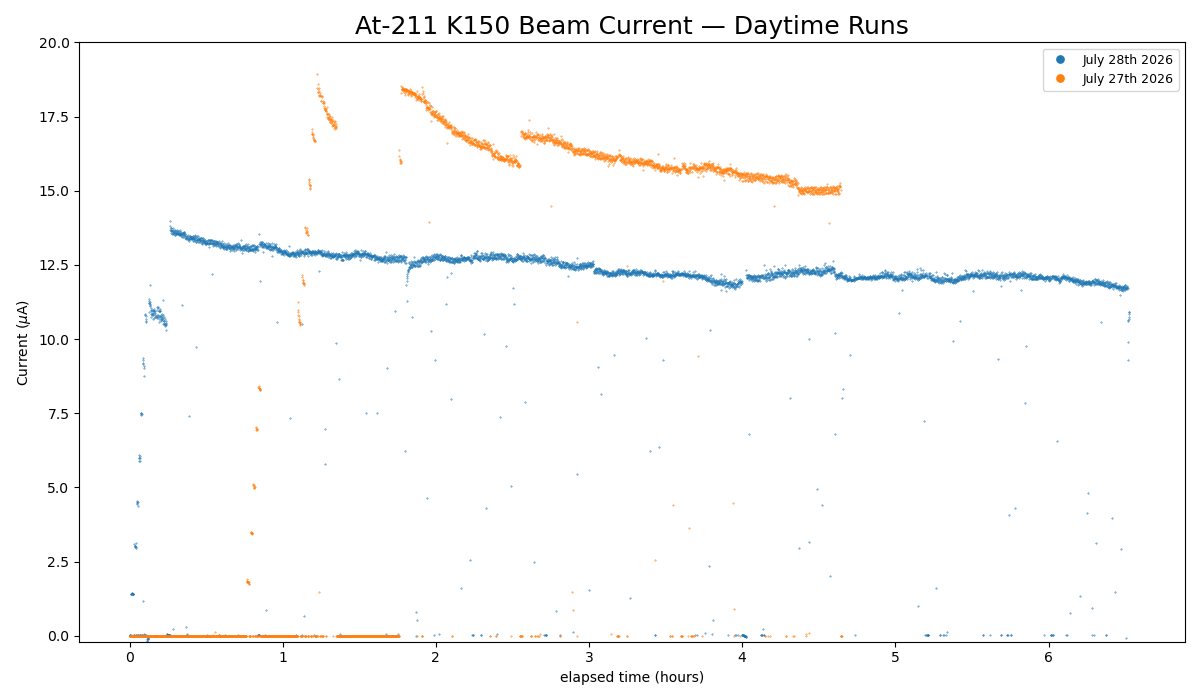

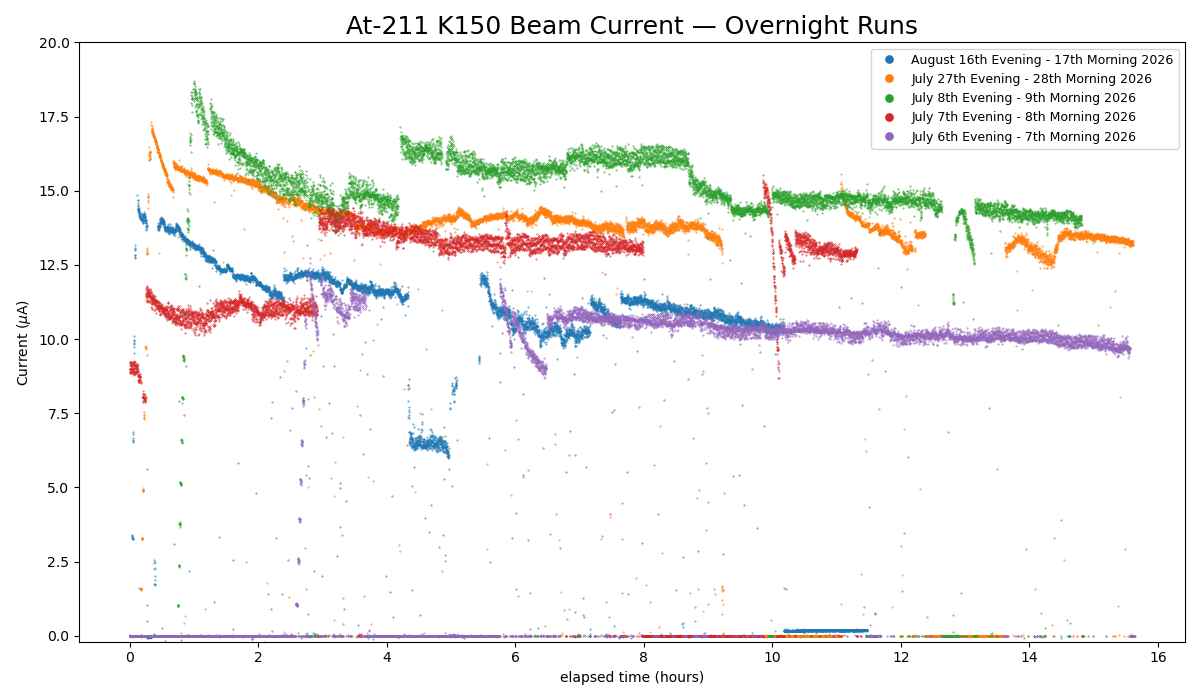

In [1]:
%matplotlib ipympl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#creating paths and titles same as previous graphs. adding groups for separating shorter and longer runs.
runs = [{'path' : 'C:/users/willm/At-211/Current Data/Current_Aug27morning_2026.dat', 'title' : 'August 16th Evening - 17th Morning 2026', 'group' : 'overnight'},
        {'path' : 'C:/users/willm/At-211/Current Data/Current_Jul28afternoon_2026.dat', 'title' : 'July 28th 2026', 'group' : 'daytime'},
        {'path' : 'C:/users/willm/At-211/Current Data/Current_Jul28morning_2026.dat', 'title' : 'July 27th Evening - 28th Morning 2026', 'group' : 'overnight'},
        {'path' : 'C:/users/willm/At-211/Current Data/CurrentJul_27morning_2026.dat', 'title' : 'July 27th 2026', 'group' : 'daytime'},
        {'path' : 'C:/users/willm/At-211/Current Data/CurrentJul8_9_2026.dat', 'title' : 'July 8th Evening - 9th Morning 2026', 'group' : 'overnight'},
        {'path' : 'C:/users/willm/At-211/Current Data/Current_july_8_2026.dat', 'title' : 'July 7th Evening - 8th Morning 2026', 'group' : 'overnight'},
        {'path' : 'C:/users/willm/At-211/Current Data/Current_Jul6_7_2026.dat', 'title' : 'July 6th Evening - 7th Morning 2026', 'group' : 'overnight'}]

groups = ['overnight', 'daytime']
figs, axs = {}, {}
for i in groups: # creating figure
    fig, ax = plt.subplots(figsize=(12, 7))
    figs[i], axs[i] = fig, ax

# setting up color pallette
col_palette = plt.cm.tab10(np.linspace(0, 1, 10)) #cm.table found using claude troubleshooting
color_index = {i: 0 for i in groups}

for run in runs:

    df = pd.read_csv(run['path'], skiprows = 1, header = None, names = [ 'date', 'time', 'na1','na2','na3', 'current', 'dashes', 'node'], sep = ' ')
    data = df[['date','time','current']].copy()

    # time of day
    t = pd.to_datetime(data['time'], format = '%H:%M:%S')
    secs_since_midnight = t.dt.hour*3600 + t.dt.minute*60 + t.dt.second

    # correct for midnight rollover
    rollovers = (secs_since_midnight.diff() < 0).cumsum()
    secs_adjusted = secs_since_midnight + rollovers * 86400

    # elapsed hours since the start of this specific run so runs starting at different clock times still overlay starting at t=0
    elapsed_hours = (secs_adjusted - secs_adjusted.iloc[0]) / 3600

    uamps = data['current'] * 1e6

    ax = axs[run['group']]
    color = col_palette[color_index[run['group']] % 10]
    ax.plot(elapsed_hours, uamps, '.', markersize=0.7, color=color, label=run['title'])
    color_index[run['group']] += 1

# place all data sets into figure
for i in groups:
    ax = axs[i]
    ax.set_xlabel('elapsed time (hours)')
    ax.set_ylabel(r'Current ($\mu$A)')
    ax.set_ylim(-0.2, 20)
    ax.set_title(f'At-211 K150 Beam Current — {i.capitalize()} Runs', fontsize=18)
    leg = ax.legend(markerscale=15, fontsize=9, loc='upper right')
    figs[i].tight_layout()

plt.show()

In [7]:
print([r['group'] for r in runs])

['overnight', 'daytime', 'overnight', 'daytime', 'overnight', 'overnight', 'overnight']
